# Seasonal Temperature Extremes and Tropical Nights Analysis

This notebook calculates the 95th percentile of daily maximum and minimum temperatures for a user-defined season. It generates spatial maps of the temporal mean and time-series plots showing the evolution of each indicator. The same spatial and temporal analyses are also performed for the annual number of tropical nights.

### Imports:
Libraries required to run the script

In [1]:
import sys
sys.path.append("..")
from utils.Urban_Rural_functions import get_daily_min_or_max_fields, save_figures
import numpy as np
import xarray as xr
from urclimask.utils import kelvin2degC
from xclim.indices.generic import threshold_count
import matplotlib.pyplot as plt
from utils.ExtremeFunctions import figure
from pathlib import Path
from xclim.indices import generic as xcig

### Variables:

Below there are defined the data configuration, the temperature threshold used to identify tropical nights, the index from xclim to calculate temperatures above a value and the months included in the season to be analyzed. In case you want to use other index from xclim, change the index_name value. Be carefull with the index atributes.

In [2]:
#City name and data info:
variable = 'tas'
driving_model = 'ERA5'
scenario = 'evaluation'
member = 'r1i1p1f1'
institution = 'BCCR-UCAN'
model = 'WRF451R-CI4C'
version = 'v1-r1'
time_period = '1hr'
data_version = 'v20240710'
city='Paris'

In [3]:
#Interpolated data path:
data_path = '../I4C_CPRCM_CITY_DATA/'

# Obtaination of the domain from the city_name
if city == 'Paris' or city == 'Barcelona' or city == 'Prague':
    # domain = 'ALPX-3i' 
    domain = 'ALPX-3f'#For my data, the current version is called ALPX-3i.
elif city == 'Bergen' or city == 'Hamburg' or city == 'NewCastle':
    domain = 'NSEA-3i'

# Temperature threshold
T_lim = 20 #Temperature of tropical nights in °C. If the minimum temperature is above this threshold, it is considered a tropical night.

#xclim index to use:
index_name = 'threshold_count'
index_function = getattr(xcig, index_name)

# Define the atribute included in the data after the xclim index aplication
xclim_operation_name = 'Tropical nights'

# Months to be analyzed (summer in this case)
season_months = [6, 7, 8]

#List to save figures at the end of the notebook
figures = []

### Data loading, month selection, calculation of daily minimum and maximum temperatures, and mask application

From the variables defined above, it is construct the file path and name for the input data. The data is readden, the degrees are converted to celsius if need it, and the maximum and minimum temperatures are obtained using the get_daily_min_or_max_fields function defined in Urban_Rurarl_functions.py

In [4]:
# # Open data:
path = f'{data_path}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_period}/{variable}/{data_version}/' 
file = variable + '_' + domain + '_' + driving_model + '_' + scenario + '_' + member + '_' + institution + '_' + model + '_' + version + '_' + time_period + '_' + city + '_cropped_interpolated.nc'
ds = xr.open_dataset(path+file)
ds = kelvin2degC(ds, variable)#K->ºC
data=ds[variable]

# Minimum and maximum temperature obtention:
ds_min = get_daily_min_or_max_fields(data, 'minimum')
ds_max = get_daily_min_or_max_fields(data, 'maximum')

In the next cell, the urban and rural masks are applied to the datasets. 

In [5]:
## Apply the mask:

# Read the mask:
output_dir = '../utils/urclimask_Results'# Name of the output masks directory
urmask = xr.open_dataset(f"{output_dir}/{city}_{domain}_{model}_urban_rural_mask.nc")

#Definition of urban and rural masks:
rural_mask = urmask.urmask == 0
urban_mask = urmask.urmask == 1

# Apply it:
ds_min_rural = ds_min.where(rural_mask)
ds_min_urban = ds_min.where(urban_mask)
ds_max_rural = ds_max.where(rural_mask)
ds_max_urban = ds_max.where(urban_mask)

In the next cell, the season is extracted from the data. The selected months are printed. They can be changed in the variables section.

In [6]:
#Rememember the months used for the calculus:
print('The months used for the calculus are: ', season_months)

## Extract seasons:
season_ds_min_rural = ds_min_rural.sel(time=ds_min_rural.time.dt.month.isin(season_months))
season_ds_min_urban = ds_min_urban.sel(time=ds_min_urban.time.dt.month.isin(season_months))
season_ds_max_rural = ds_max_rural.sel(time=ds_max_rural.time.dt.month.isin(season_months))
season_ds_max_urban = ds_max_urban.sel(time=ds_max_urban.time.dt.month.isin(season_months))
season_ds_min = ds_min.sel(time=ds_min.time.dt.month.isin(season_months))
season_ds_max = ds_max.sel(time=ds_max.time.dt.month.isin(season_months))

The months used for the calculus are:  [6, 7, 8]


### Tropical nights:
Using threshold_count xclim index, there are count the number of days where the minimum temperature is above 20°C (tropical nights) for each year in the dataset.

In [7]:
#Apply the xclim index:
n_values_urban = index_function(da=season_ds_min_urban, op=">", threshold=T_lim, freq="YS")
n_values_rural = index_function(da=season_ds_min_rural, op=">", threshold=T_lim, freq="YS")

#Reapplication of the mask to remove zero values from the area surrounding the region of interest.
n_values_urban = n_values_urban.where(urban_mask)
n_values_rural = n_values_rural.where(rural_mask)

# Include an attribute
n_values_urban.attrs["xclim_operation"] = xclim_operation_name
n_values_rural.attrs["xclim_operation"] = xclim_operation_name

#### Mean number of tropical nights per year in urban and rural areas representation:

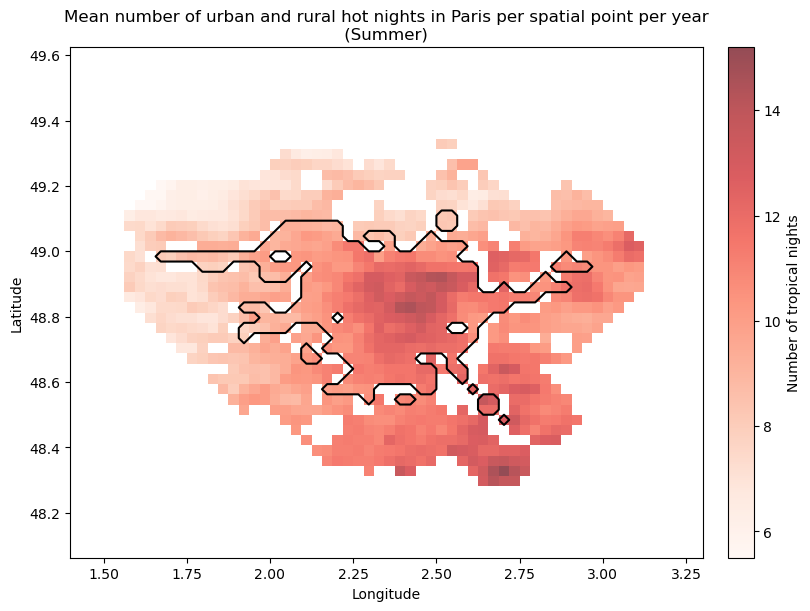

In [8]:
fig = figure(n_values_urban, n_values_rural, variable, city, urmask, season_months)
figures.append(fig)

#### Change of tropical nights in urban and rural areas over the years:
Below, there is represented the number of tropical nights per year for the data period. The values may be decimal numbers because they are obtained by spatially averaging the grid cells.

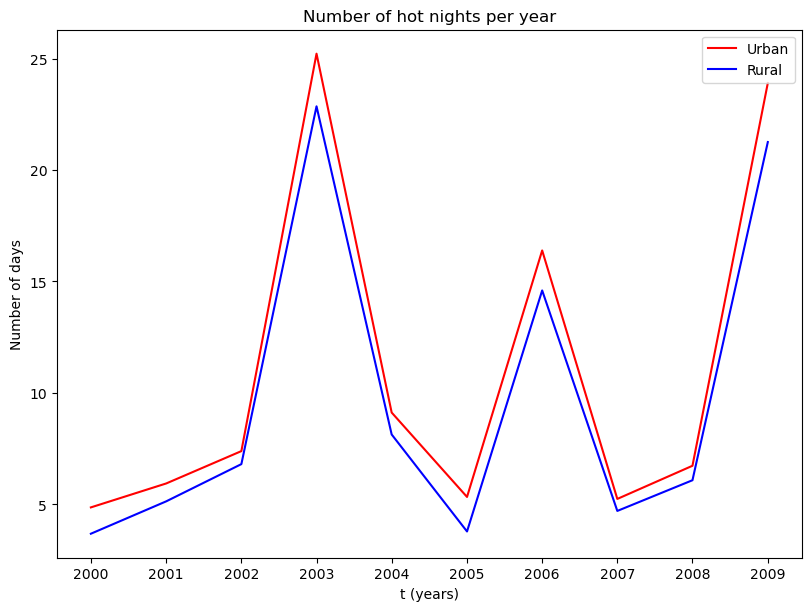

In [9]:
# Figure:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
n_values_urban.mean(dim="lon").mean(dim="lat").plot(ax=ax, label="Urban", color="red")
n_values_rural.mean(dim="lon").mean(dim="lat").plot(ax=ax, label="Rural", color="blue")

ax.set_title("Number of hot nights per year")
ax.set_xlabel('t (years)')
ax.set_ylabel(f"Number of days")
ax.legend()

plt.show()
figures.append(fig)

#### Difference between urban and rural number of tropical nights per year:

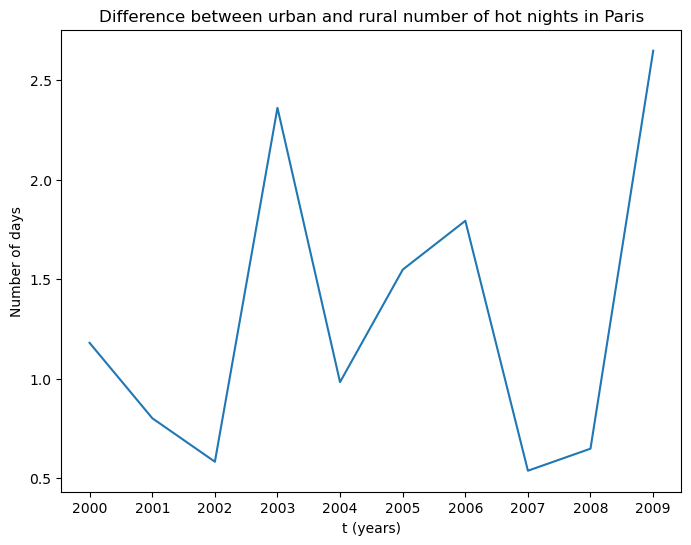

In [10]:
##Difference between urban and rural values figure:
fig, ax = plt.subplots(figsize=(8, 6))
diff=n_values_urban.mean(dim="lon").mean(dim="lat")-n_values_rural.mean(dim="lon").mean(dim="lat")
diff.plot(ax=ax)
ax.set_title(f"Difference between urban and rural number of hot nights in {city}")
ax.set_xlabel('t (years)')
ax.set_ylabel(f"Number of days")
figures.append(plt.gcf())

### Calculation of 95th  percentile:

In [11]:
# 95th percentile calculation: equal to the 0.95 quantile
p95_season_ds_min_rural = season_ds_min_rural.resample(time="YS").quantile(0.95, dim="time")
p95_season_ds_min_urban = season_ds_min_urban.resample(time="YS").quantile(0.95, dim="time")
p95_season_ds_max_rural = season_ds_max_rural.resample(time="YS").quantile(0.95, dim="time")
p95_season_ds_max_urban = season_ds_max_urban.resample(time="YS").quantile(0.95, dim="time")

# Include an attribute
p95_season_ds_min_rural.attrs["xclim_operation"] = 'min_95percentile'
p95_season_ds_min_urban.attrs["xclim_operation"] = 'min_95percentile'
p95_season_ds_max_rural.attrs["xclim_operation"] = 'max_95percentile'
p95_season_ds_max_urban.attrs["xclim_operation"] = 'max_95percentile'

/nfs/home/gmeteo/moralesi/prueba_servidor/Y/envs/netcdf/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


#### Mean 95th percentile per year in urban and rural areas for the minimum and maximum variable values:

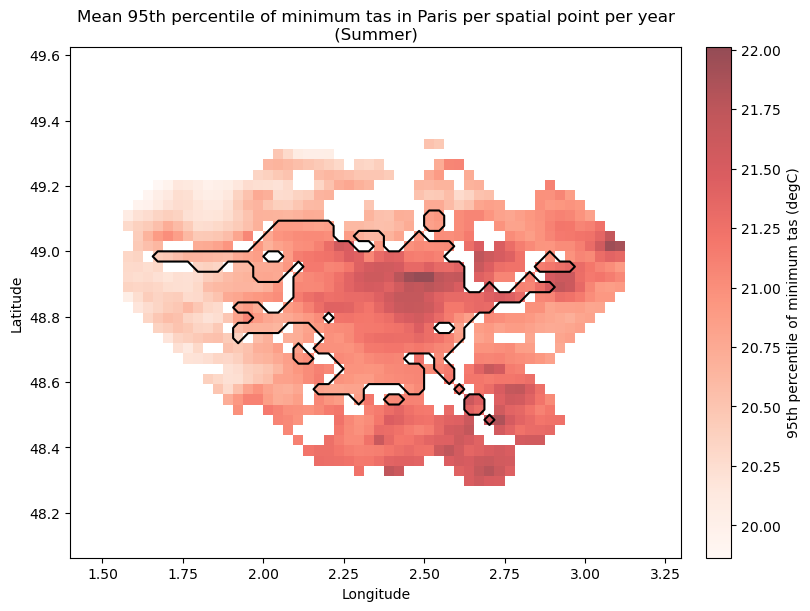

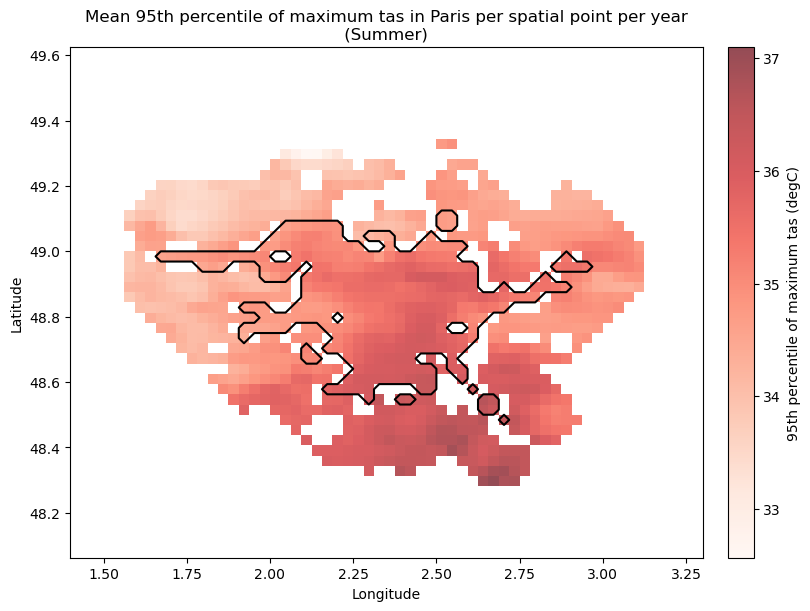

In [12]:
fig = figure(p95_season_ds_min_urban, p95_season_ds_min_rural, variable, city, urmask, season_months)
figures.append(fig)
fig = figure(p95_season_ds_max_urban, p95_season_ds_max_rural, variable, city, urmask, season_months)
figures.append(fig)

#### Change of 95th percentile in urban and rural areas over the years for the minimum and maximum variable values:

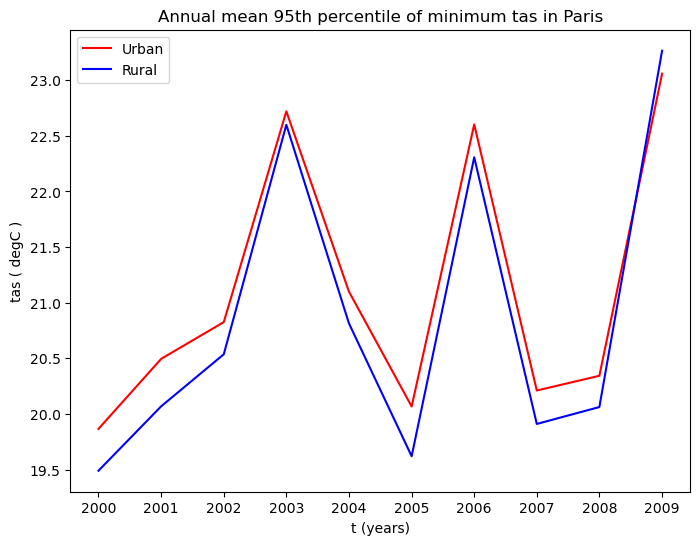

In [13]:
#Figure for the daily minimum of the variable
fig, ax = plt.subplots(figsize=(8, 6))
p95_season_ds_min_urban.mean(dim="lon").mean(dim="lat").plot(ax=ax, label="Urban", color="red")
p95_season_ds_min_rural.mean(dim="lon").mean(dim="lat").plot(ax=ax, label="Rural", color="blue")

ax.set_title(f"Annual mean 95th percentile of minimum {variable} in {city}")
ax.set_xlabel('t (years)')
ax.set_ylabel(f"{variable} ( {p95_season_ds_min_urban.attrs['units']} )")
ax.legend()

plt.show()
figures.append(fig)

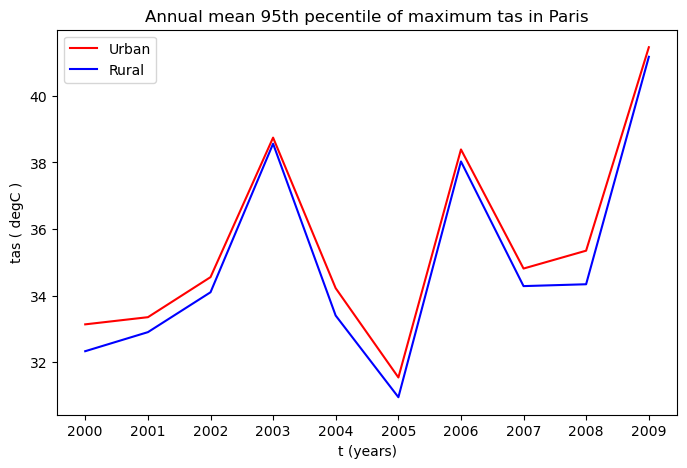

In [14]:
#Figure for the daily maximum of the variable
fig, ax = plt.subplots(figsize=(8, 5))
p95_season_ds_max_urban.mean(dim="lon").mean(dim="lat").plot(ax=ax, label="Urban", color="red")
p95_season_ds_max_rural.mean(dim="lon").mean(dim="lat").plot(ax=ax, label="Rural", color="blue")

ax.set_title(f"Annual mean 95th pecentile of maximum {variable} in {city}")
# ax.set_xlabel("Longitud")
ax.set_xlabel('t (years)')
ax.set_ylabel(f"{variable} ( {p95_season_ds_max_urban.attrs['units']} )")
ax.legend()

plt.show()
figures.append(fig)

#### Difference between urban and rural 95th pecentile for maximum and minimum temperature: 

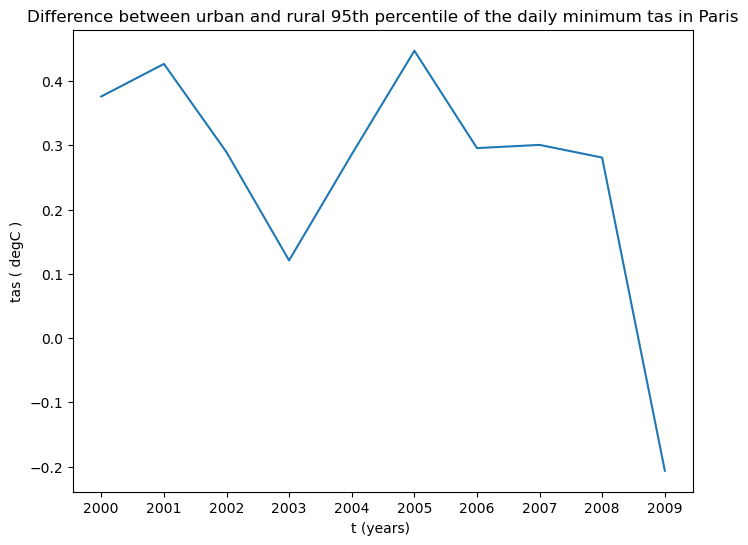

In [15]:
##Difference between urban and rural values for the daily minimun:
fig, ax = plt.subplots(figsize=(8, 6))
diff=p95_season_ds_min_urban.mean(dim="lon").mean(dim="lat")-p95_season_ds_min_rural.mean(dim="lon").mean(dim="lat")

# Figure:
diff.plot(ax=ax)
ax.set_title(f"Difference between urban and rural 95th percentile of the daily minimum {variable} in {city}")
ax.set_xlabel('t (years) ')
ax.set_ylabel(f"{variable} ( {p95_season_ds_min_urban.attrs['units']} )")
figures.append(plt.gcf())

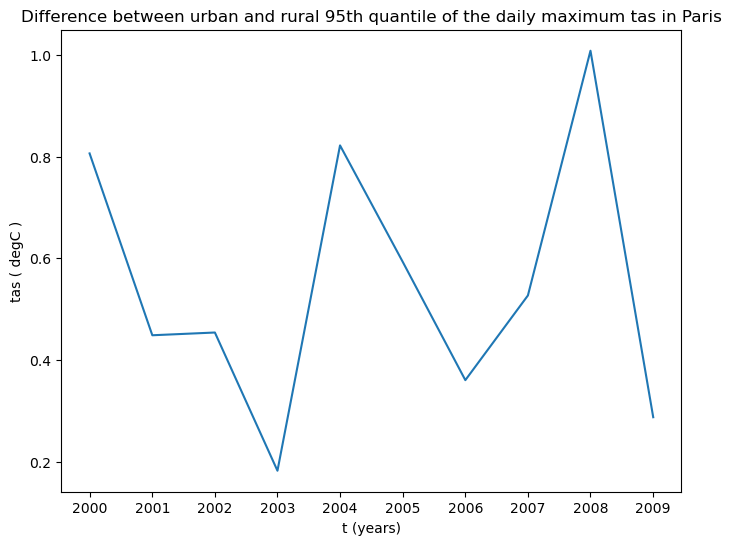

In [16]:
##Difference between mean urban and rural values for the daily maximum:
fig, ax = plt.subplots(figsize=(8, 6))
diff=p95_season_ds_max_urban.mean(dim="lon").mean(dim="lat")-p95_season_ds_max_rural.mean(dim="lon").mean(dim="lat")

#Figure:
diff.plot(ax=ax)
ax.set_title(f"Difference between urban and rural 95th quantile of the daily maximum {variable} in {city}")
ax.set_xlabel('t (years)')
ax.set_ylabel(f"{variable} ( {p95_season_ds_max_urban.attrs['units']} )")
figures.append(plt.gcf())

### Generation of a summary figure using the same code structure as in File_3:

In [17]:
# Use save_figure for saving figures
positioned_figures = [
         (figures[0], 0, 0),
         (figures[3], 1, 0),
         (figures[4], 2, 0),
         (figures[1], 0, 1),
         (figures[5], 1, 1),
         (figures[6], 2, 1),
         (figures[2], 0, 2),
         (figures[7], 1, 2),
         (figures[8], 2, 2)]

info_text = (
    f"Files: {path}+{file}" )

#Path and file name for the final image:
output_dir2 = (Path(f"../extremes_figures/{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_period}/{variable}/{data_version}/{city}/"))
output_path = (output_dir2 / f"{domain}_{driving_model}_{scenario}_{member}_{institution}_{model}_{version}_{variable}_extremes_figures.png")

# Save figures:
combined = save_figures(
    positioned_figures,
    output_path,
    info_text,)